# 🏆 World Cup 2026 — Scenario Explorer

Interactive front-end for the `wc2026` engine: live standings, clinch/
eliminate status, what-a-team-needs, hypothetical scenarios, qualification
odds, and how much a single game matters.

**How to use:** run the **Setup** cell once (top to bottom), then run any
section below. Edit the variables at the top of each cell (e.g. `TEAM = ...`)
and re-run that cell.

> Uses the 2026 rules: 12 groups → top 2 + best-8 third-placed teams, with
> head-to-head ranked above overall goal difference.

## 1. Setup  — run this first

In [1]:
import os, sys

# Make sure the wc2026 package is importable (run Jupyter from the project
# folder, or set PROJECT_DIR to the world-cup-2026 directory).
PROJECT_DIR = os.getcwd()
if not os.path.isdir(os.path.join(PROJECT_DIR, 'wc2026')):
    # fall back: maybe the notebook lives one level up
    cand = os.path.join(PROJECT_DIR, 'world-cup-2026')
    if os.path.isdir(os.path.join(cand, 'wc2026')):
        PROJECT_DIR = cand
sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)

from wc2026 import data, analysis
from wc2026.tiebreakers import (group_rows, project, all_groups,
                                teams_in_group, find_group)

# optional niceties
try:
    import pandas as pd; HAVE_PD = True
except ImportError:
    HAVE_PD = False
try:
    import matplotlib.pyplot as plt; HAVE_PLT = True
except ImportError:
    HAVE_PLT = False

print('pandas:', HAVE_PD, '| matplotlib:', HAVE_PLT)

pandas: True | matplotlib: True


### Load results
Uses `cache.json` (your live data from `fetch`) if present, else the bundled
`sample_data.json`. Re-run this cell after re-fetching to refresh.

In [2]:
DATA_FILE = 'cache.json' if os.path.exists('cache.json') else 'sample_data.json'
MATCHES = data.load_file(DATA_FILE)
META = data.load_meta('meta.json')

ALL_TEAMS = sorted({t for g in all_groups(MATCHES) for t in teams_in_group(g, MATCHES)})
played = sum(1 for m in MATCHES if m.played)
print(f'Loaded {DATA_FILE}: {len(MATCHES)} matches, {played} played, {len(ALL_TEAMS)} teams.')

def resolve_team(q):
    """Match a team name (case-insensitive substring)."""
    lo = q.lower()
    exact = [t for t in ALL_TEAMS if t.lower() == lo]
    if exact: return exact[0]
    hits = [t for t in ALL_TEAMS if lo in t.lower()]
    if len(hits) == 1: return hits[0]
    if not hits: raise ValueError(f"No team matches '{q}'. Try one of: "
                                  + ', '.join(ALL_TEAMS))
    raise ValueError(f"'{q}' is ambiguous: " + ', '.join(hits))

Loaded cache.json: 72 matches, 36 played, 48 teams.


### (optional) Fetch fresh live data
Paste your football-data.org token and run. The engine auto-respects the
API's rate-limit headers. Then re-run the **Load results** cell above.

In [ ]:
TOKEN = os.environ.get('FOOTBALL_DATA_TOKEN', '')  # paste your token here or set the env var

if TOKEN:
    matches = data.fetch_live(TOKEN)
    data.save_file('cache.json', matches)
    # refresh in-memory data so you don't have to re-run the Load cell
    MATCHES = data.load_file('cache.json')
    ALL_TEAMS = sorted({t for g in all_groups(MATCHES) for t in teams_in_group(g, MATCHES)})
    played = sum(1 for m in MATCHES if m.played)
    print(f'Fetched {len(MATCHES)} matches ({played} played) -> cache.json')

    # how recent is the SOURCE data (the provider's clock, not your fetch time)?
    f = data.source_freshness(MATCHES)
    if f['source_as_of']:
        age = (f['now'] - f['source_as_of']).total_seconds() / 60
        print(f"Data is from: {f['source_as_of'].strftime('%Y-%m-%d %H:%M UTC')} "
              f"({age:.0f} min ago)")
        c = f['counts']
        print(f"  {c['finished']} finished, {c['live']} in progress, {c['scheduled']} upcoming")
        lf = f['latest_finished']
        if lf:
            print(f"  Most recent result: {lf.home} {lf.home_goals}-{lf.away_goals} {lf.away}")
        for m in f['live_matches']:
            print(f"  ▶ live now: {m.home} vs {m.away}")
else:
    print('No token set — skipping. Set TOKEN above to fetch live data.')

## 2. Standings
All groups, correct 2026 tiebreakers. ✅ = currently qualifying; the last
table is the cross-group race for the 8 best third-placed spots.

In [4]:
from IPython.display import display, Markdown

def standings(group=None):
    proj = project(MATCHES, META)
    qthird = set(proj.qualified_thirds)
    groups = [group.upper()] if group else all_groups(MATCHES)
    for g in groups:
        rows = group_rows(g, MATCHES, META)
        data_rows = []
        for i, r in enumerate(rows, 1):
            note = '✅' if i <= 2 else ('✅ 3rd' if i == 3 and r.team in qthird
                                       else ('· 3rd' if i == 3 else ''))
            data_rows.append({'#': i, 'Team': r.team, 'P': r.played,
                              'W': r.won, 'D': r.drawn, 'L': r.lost,
                              'GF': r.gf, 'GA': r.ga, 'GD': r.gd,
                              'Pts': r.points, '': note})
        if HAVE_PD:
            display(Markdown(f'**Group {g}**'))
            display(pd.DataFrame(data_rows).set_index('#'))
        else:
            print(f'\nGroup {g}')
            for d in data_rows:
                print(f"  {d['#']} {d['Team']:<22} {d['Pts']} pts  "
                      f"GD {d['GD']:+d}  {d['']}")
    if group is None:
        display(Markdown('**Best third-placed teams (top 8 qualify)**'))
        tr = [{'Rank': i, 'In?': '✅' if i <= 8 else '❌', 'Group': r.group,
               'Team': r.team, 'Pts': r.points, 'GD': r.gd, 'GF': r.gf}
              for i, r in enumerate(proj.thirds_ranked, 1)]
        display(pd.DataFrame(tr).set_index('Rank') if HAVE_PD else tr)

standings()           # standings('A') for a single group

**Group A**

,Team,P,W,D,L,GF,GA,GD,Pts,
#,,,,,,,,,,
1,Mexico,2,2,0,0,3,0,3,6,✅
2,South Korea,2,1,0,1,2,2,0,3,✅
3,Czechia,2,0,1,1,2,3,-1,1,✅ 3rd
4,South Africa,2,0,1,1,1,3,-2,1,


**Group B**

,Team,P,W,D,L,GF,GA,GD,Pts,
#,,,,,,,,,,
1,Canada,2,1,1,0,7,1,6,4,✅
2,Switzerland,2,1,1,0,5,2,3,4,✅
3,Bosnia-Herzegovina,2,0,1,1,2,5,-3,1,· 3rd
4,Qatar,2,0,1,1,1,7,-6,1,


**Group C**

...

,Team,P,W,D,L,GF,GA,GD,Pts,
#,,,,,,,,,,
1,Colombia,1,1,0,0,3,1,2,3,✅
2,Portugal,1,0,1,0,1,1,0,1,✅
3,Congo DR,1,0,1,0,1,1,0,1,✅ 3rd
4,Uzbekistan,1,0,0,1,1,3,-2,0,


**Group L**

,Team,P,W,D,L,GF,GA,GD,Pts,
#,,,,,,,,,,
1,England,1,1,0,0,4,2,2,3,✅
2,Ghana,1,1,0,0,1,0,1,3,✅
3,Panama,1,0,0,1,0,1,-1,0,· 3rd
4,Croatia,1,0,0,1,2,4,-2,0,


**Best third-placed teams (top 8 qualify)**

,In?,Group,Team,Pts,GD,GF
Rank,,,,,,
1,✅,F,Sweden,3,0,6
2,✅,C,Scotland,3,0,1
3,✅,D,Paraguay,3,-2,2
4,✅,G,Belgium,1,0,1
5,✅,K,Congo DR,1,0,1
6,✅,H,Spain,1,0,0
7,✅,A,Czechia,1,-1,2
8,✅,E,Ecuador,1,-1,0
9,❌,B,Bosnia-Herzegovina,1,-3,2


## 3. Team status — clinched / eliminated / alive
Group placement is computed *exactly* by enumerating remaining group results.

In [5]:
TEAM = 'Scotland'    # <-- edit me

t = resolve_team(TEAM)
s = analysis.team_status(t, MATCHES, META)
ordd = {1:'1st',2:'2nd',3:'3rd',4:'4th'}
print(f"{t}  (Group {s['group']})")
print(f"  Now: {ordd[s['current_position']]}, {s['current_points']} pts, "
      f"GD {s['current_gd']:+d}, {s['remaining_in_group']} group game(s) left")
print(f"  Possible final positions: "
      f"{', '.join(ordd[p] for p in s['possible_positions'])}")
print(f"\n  >> {s['headline']}")
if s['level'] == 'alive-third' and s.get('current_third_rank'):
    v = 'would QUALIFY' if s['current_projection_qualified'] else 'would be OUT'
    print(f"     Currently the #{s['current_third_rank']} third-placed team -> {v}.")
    print('     Use section 6 (odds) for the third-place race.')

Scotland  (Group C)
  Now: 3rd, 3 pts, GD +0, 2 group game(s) left
  Possible final positions: 1st, 2nd, 3rd

  >> ALIVE — still controls a path to winning the group.


## 4. What does a team need from its next game?

In [6]:
TEAM = 'Turkey'        # <-- edit me

t = resolve_team(TEAM)
r = analysis.what_they_need(t, MATCHES, META)
if r.get('no_more_games'):
    print(f'{t} has finished its group games.')
else:
    print(f"{t} — next game: {r['fixture']}\n")
    label = {'W':'WIN ', 'D':'DRAW', 'L':'LOSE'}
    for res in ('W','D','L'):
        if res not in r['summary']: continue
        g = r['summary'][res]['guaranteed']; b = r['summary'][res]['best']
        guar = analysis._POS_MEANING[g]
        if g == b:
            print(f'  If they {label[res]}: guaranteed to {guar}.')
        else:
            print(f'  If they {label[res]}: at worst {guar}; '
                  f'at best {analysis._POS_MEANING[b]}.')

Turkey — next game: Turkey vs United States

  If they WIN : guaranteed to finish last (eliminated).
  If they DRAW: guaranteed to finish last (eliminated).
  If they LOSE: guaranteed to finish last (eliminated).


## 5. Scenario — plug in hypothetical results
List results as `"Team A 2-1 Team B"`. Then see the projected effect.

In [7]:
RESULTS = ['Turkey 1-1 Paraguay']   # <-- edit me (add more in the list)
FOCUS_TEAM = 'Turkey'                  # or None for the whole picture

import re
def parse(spec):
    m = re.match(r'^(.*?)\s+(\d+)\s*-\s*(\d+)\s+(.*)$', spec.strip())
    t1,g1,g2,t2 = m.groups(); return (t1.strip(), int(g1), int(g2), t2.strip())

new = analysis.apply_overrides(MATCHES, [parse(s) for s in RESULTS])
proj = project(new, META)
print('Applied:'); [print('  ', s) for s in RESULTS]
if FOCUS_TEAM:
    t = resolve_team(FOCUS_TEAM)
    s = analysis.team_status(t, new, META)
    print(f'\nEffect on {t}:\n  >> {s["headline"]}')
    print('  Projected:', 'IN ✅' if t in proj.qualified() else 'OUT ❌')
    print(f'\nProjected Group {s["group"]}:')
    for i, row in enumerate(proj.group_order[s['group']], 1):
        print(f'  {i}. {row.team:<22} {row.points} pts, GD {row.gd:+d}')
else:
    print('\nWinners:   ', ', '.join(proj.winners))
    print('Runners-up:', ', '.join(proj.runners_up))
    print('Best 3rds: ', ', '.join(proj.qualified_thirds))

Applied:
   Turkey 1-1 Paraguay

Effect on Turkey:
  >> ALIVE — can still finish top 2 (automatic qualification).
  Projected: IN ✅

Projected Group D:
  1. United States          6 pts, GD +5
  2. Australia              3 pts, GD +0
  3. Turkey                 1 pts, GD -2
  4. Paraguay               1 pts, GD -3


## 6. Qualification odds (Monte Carlo)
Simulates every remaining game many times. This is how the third-place race
is resolved (it depends on all 12 groups at once).

,Reach R32 %
Team,
Mexico,100.0
Canada,100.0
Switzerland,100.0
United States,100.0
Germany,100.0
Netherlands,100.0
Japan,100.0
Brazil,100.0
Morocco,99.9


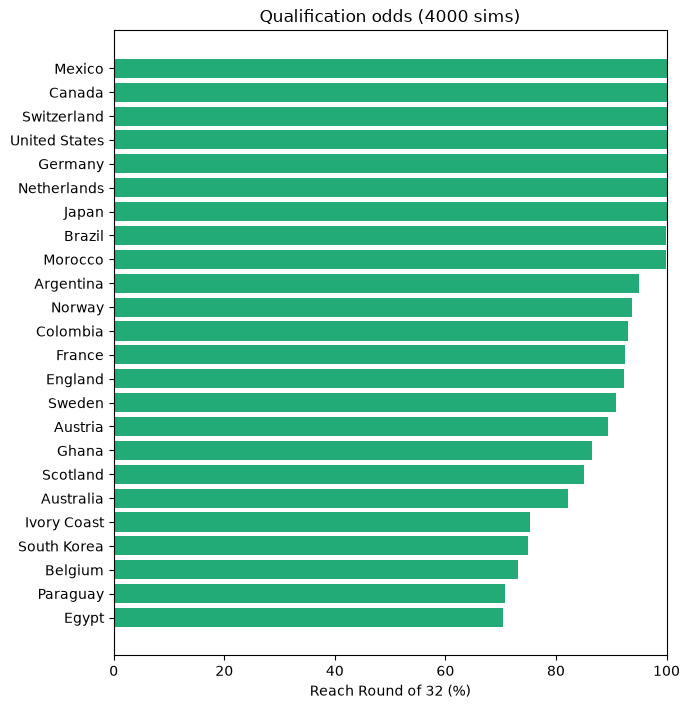

In [8]:
N = 4000
TEAM = None       # set to a team name for that team's odds, or None for a leaderboard
GROUP = None      # e.g. 'A' to restrict the leaderboard to one group

probs = analysis.monte_carlo(MATCHES, META, n=N)

if TEAM:
    t = resolve_team(TEAM); p = probs[t]
    print(f'{t} — over {N} simulations:')
    print(f"  Win group: {p['win_group']*100:5.1f}%")
    print(f"  Top 2:     {p['top2']*100:5.1f}%")
    print(f"  Reach R32: {p['qualify']*100:5.1f}%")
else:
    rows = [(t, p['qualify']) for t, p in probs.items()
            if not GROUP or find_group(t, MATCHES) == GROUP.upper()]
    rows.sort(key=lambda x: -x[1])
    if HAVE_PD:
        display(pd.DataFrame([{'Team': t, 'Reach R32 %': round(q*100,1)}
                              for t, q in rows]).set_index('Team'))
    if HAVE_PLT:
        top = rows[:24][::-1]
        plt.figure(figsize=(7, max(3, len(top)*0.3)))
        plt.barh([t for t,_ in top], [q*100 for _,q in top], color='#2a7')
        plt.xlabel('Reach Round of 32 (%)'); plt.xlim(0,100)
        plt.title(f'Qualification odds ({N} sims)'); plt.tight_layout(); plt.show()
    if not HAVE_PD and not HAVE_PLT:
        for t, q in rows[:24]: print(f'  {q*100:5.1f}%  {t}')

## 7. How much does a single game matter?
Holds one game at each of its three outcomes, simulates everything else, and
reports the swing in a team's qualification odds — the 'importance' number.

How much does 'Brazil vs Haiti' matter for Brazil?  (2000 sims)

  Brazil win                   -> reach R32 100.0%
  draw                         -> reach R32  51.2%
  Haiti win                    -> reach R32  34.9%

  Swing in Brazil's qualification odds: 65.1 percentage points.


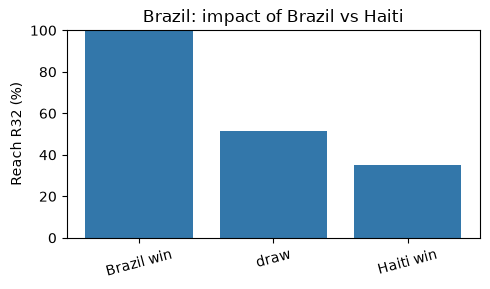

In [9]:
TEAM = 'Brazil'                 # whose fate we care about
FIXTURE = 'Brazil vs Haiti'     # 'Team A vs Team B'
N = 2000

t = resolve_team(TEAM)
h, a = re.split(r'\s+vs\s+', FIXTURE, flags=re.I)
res = analysis.game_importance(t, MATCHES, META, (h.strip(), a.strip()), n=N)
print(f"How much does '{res['fixture']}' matter for {t}?  ({N} sims)\n")
for label, q in res['by_result'].items():
    print(f'  {label:<28} -> reach R32 {q*100:5.1f}%')
print(f"\n  Swing in {t}'s qualification odds: {res['swing']*100:.1f} "
      'percentage points.')
if HAVE_PLT:
    labels = list(res['by_result']); vals = [res['by_result'][l]*100 for l in labels]
    plt.figure(figsize=(5,3)); plt.bar(labels, vals, color='#37a')
    plt.ylabel('Reach R32 (%)'); plt.ylim(0,100)
    plt.title(f"{t}: impact of {res['fixture']}")
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 8. One-team dashboard
Everything about a single team in one place: standing, status, what they
need next, and qualification odds.

In [10]:
TEAM = 'Paraguay'    # <-- edit me
DASH_N = 3000             # simulations for the odds line

def dashboard(team, n=DASH_N):
    t = resolve_team(team)
    s = analysis.team_status(t, MATCHES, META)
    g = s['group']
    ordd = {1:'1st',2:'2nd',3:'3rd',4:'4th'}
    print('=' * 56)
    print(f'  {t}   —   Group {g}')
    print('=' * 56)
    # current group picture
    for i, r in enumerate(group_rows(g, MATCHES, META), 1):
        here = '>' if r.team == t else ' '
        print(f'  {here} {i}. {r.team:<22} {r.points} pts  GD {r.gd:+d}')
    print(f"\n  STATUS: {s['headline']}")
    # what they need next
    r = analysis.what_they_need(t, MATCHES, META)
    if not r.get('no_more_games'):
        print(f"\n  NEXT GAME: {r['fixture']}")
        lab = {'W':'Win ','D':'Draw','L':'Lose'}
        for res in ('W','D','L'):
            if res not in r['summary']: continue
            gu = analysis._POS_MEANING[r['summary'][res]['guaranteed']]
            be = analysis._POS_MEANING[r['summary'][res]['best']]
            tail = f'guaranteed to {gu}' if gu == be else f'at worst {gu}; best {be}'
            print(f'    {lab[res]} -> {tail}')
    # odds
    p = analysis.monte_carlo(MATCHES, META, n=n)[t]
    print(f'\n  ODDS ({n} sims):  win group {p["win_group"]*100:.0f}%   '
          f'top 2 {p["top2"]*100:.0f}%   reach R32 {p["qualify"]*100:.0f}%')
    print('=' * 56)

dashboard(TEAM)

  Paraguay   —   Group D
    1. United States          6 pts  GD +5
    2. Australia              3 pts  GD +0
  > 3. Paraguay               3 pts  GD -2
    4. Turkey                 0 pts  GD -3

  STATUS: ALIVE — can still finish top 2 (automatic qualification).

  NEXT GAME: Paraguay vs Australia
    Win  -> guaranteed to finish 2nd (auto-qualify)
    Draw -> guaranteed to finish 3rd (qualification depends on other groups)
    Lose -> guaranteed to finish 3rd (qualification depends on other groups)

  ODDS (3000 sims):  win group 0%   top 2 37%   reach R32 71%


## 9. 🎛️ Interactive panel (GUI)

Run this cell, then just use the controls — pick a **Team**, choose a **view**
(Dashboard / Status / Needs / Odds / Importance), and drag **Sims** for the
Monte-Carlo accuracy. Everything updates automatically; no re-running cells.
(The data is whatever you last loaded — re-run the fetch cell to refresh it.)

In [11]:
import ipywidgets as W
from IPython.display import display, clear_output
_ordd = {1: '1st', 2: '2nd', 3: '3rd', 4: '4th'}


def _status_text(team):
    s = analysis.team_status(team, MATCHES, META)
    print(f"{team}   (Group {s['group']})")
    print(f"  Now: {_ordd[s['current_position']]}, {s['current_points']} pts, "
          f"GD {s['current_gd']:+d}, {s['remaining_in_group']} group game(s) left")
    print(f"  Possible final: {', '.join(_ordd[p] for p in s['possible_positions'])}")
    print(f"\n  >> {s['headline']}")
    if s['level'] == 'alive-third' and s.get('current_third_rank'):
        v = 'would QUALIFY' if s['current_projection_qualified'] else 'would be OUT'
        print(f"     #{s['current_third_rank']} third-placed team right now -> {v}")


def _needs_text(team):
    r = analysis.what_they_need(team, MATCHES, META)
    if r.get('no_more_games'):
        print(f"{team} has finished its group games."); return
    print(f"{team} — next game: {r['fixture']}\n")
    lab = {'W': 'WIN ', 'D': 'DRAW', 'L': 'LOSE'}
    for res in ('W', 'D', 'L'):
        if res not in r['summary']: continue
        g = r['summary'][res]['guaranteed']; b = r['summary'][res]['best']
        gu = analysis._POS_MEANING[g]
        if g == b:
            print(f"  If they {lab[res]}: guaranteed to {gu}")
        else:
            print(f"  If they {lab[res]}: at worst {gu}; at best {analysis._POS_MEANING[b]}")


def _odds_view(team, n):
    p = analysis.monte_carlo(MATCHES, META, n=n)[team]
    print(f"{team} — {n} simulations:")
    print(f"  Win group {p['win_group']*100:.0f}%    Top 2 {p['top2']*100:.0f}%    "
          f"Reach R32 {p['qualify']*100:.0f}%")
    if HAVE_PLT:
        plt.figure(figsize=(4, 2.4))
        plt.bar(['Win group', 'Top 2', 'Reach R32'],
                [p['win_group']*100, p['top2']*100, p['qualify']*100], color='#2a7')
        plt.ylim(0, 100); plt.ylabel('%'); plt.title(team)
        plt.tight_layout(); plt.show()


def _importance_view(team, n):
    g = find_group(team, MATCHES)
    nm = next((m for m in analysis.remaining(MATCHES, g)
               if team in (m.home, m.away)), None)
    if nm is None:
        print(f"{team} has no upcoming group game to weigh."); return
    res = analysis.game_importance(team, MATCHES, META, (nm.home, nm.away), n=n)
    print(f"Impact of '{res['fixture']}' on {team}  ({n} sims):")
    for label, q in res['by_result'].items():
        print(f"  {label:<26} -> reach R32 {q*100:.0f}%")
    print(f"\n  Swing: {res['swing']*100:.0f} percentage points")
    if HAVE_PLT:
        labels = list(res['by_result']); vals = [res['by_result'][l]*100 for l in labels]
        plt.figure(figsize=(4.5, 2.4)); plt.bar(labels, vals, color='#37a')
        plt.ylim(0, 100); plt.ylabel('Reach R32 %'); plt.xticks(rotation=12)
        plt.title(res['fixture']); plt.tight_layout(); plt.show()


def _dashboard_view(team, n):
    _status_text(team); print('\n' + '-' * 40)
    _needs_text(team); print('-' * 40)
    _odds_view(team, n)


# ---- widgets ----
_default = 'United States' if 'United States' in ALL_TEAMS else ALL_TEAMS[0]
team_dd = W.Dropdown(options=ALL_TEAMS, value=_default, description='Team:')
view_tb = W.ToggleButtons(options=['Dashboard', 'Status', 'Needs', 'Odds', 'Importance'],
                          value='Dashboard')
n_sl = W.IntSlider(value=3000, min=500, max=8000, step=500, description='Sims:',
                   continuous_update=False)
out = W.Output()


def _render(*_):
    with out:
        clear_output(wait=True)
        team, view, n = team_dd.value, view_tb.value, n_sl.value
        try:
            {'Dashboard': lambda: _dashboard_view(team, n),
             'Status': lambda: _status_text(team),
             'Needs': lambda: _needs_text(team),
             'Odds': lambda: _odds_view(team, n),
             'Importance': lambda: _importance_view(team, n)}[view]()
        except Exception as e:
            print('Error:', e)


for _w in (team_dd, view_tb, n_sl):
    _w.observe(_render, names='value')

display(W.VBox([W.HBox([team_dd, view_tb]), n_sl, out]))
_render()